In [ ]:
# load in dual graph
# read shape file
# find spanning tree, find an edge to cut that keeps population balanced and keep doing that 

In [1]:
from gerrychain import Graph
from gerrychain import (GeographicPartition, Partition, Graph, MarkovChain, proposals, updaters, constraints, accept, Election)
from gerrychain.proposals import recom, propose_random_flip
from gerrychain.tree import recursive_tree_part, bipartition_tree, find_balanced_edge_cuts_memoization
from gerrychain.metrics import efficiency_gap, mean_median, polsby_popper, partisan_bias
from gerrychain.updaters import cut_edges

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx

In [4]:
graph = Graph.from_json("./NC_Processed/output/NC_Processed_Precincts.json")
df = gpd.read_file("./NC_Processed/output/NC_Processed_Precincts.shp")

In [ ]:
import json
import random
import networkx as nx
import geopandas as gpd
from tqdm import tqdm

def run_wilson_partition(data_path="./NC_Processed/NC_Processed_Precincts.json", 
                          shp_path="./NC_Processed/NC_Processed_Precincts.shp", 
                          initialization=None, 
                          epsilon=0.1, 
                          balance_threshold=0.15):
    # Load graph data
    with open(data_path) as f:
        data = json.load(f)
    nodes = data["nodes"]
    links = data["links"]

    # Build graph
    g = nx.Graph()
    g.add_nodes_from(range(len(nodes)))
    for link in links:
        u, v = link["source"], link["target"]
        g.add_edge(u, v)

    # Load shapefile
    df = gpd.read_file(shp_path)
    ideal = df["TOTPOP"].sum() / 2

    # --- Inner: Wilson's algorithm ---
    def wilsons(g):
        spanning_tree_edges = set()
        visited = set()
        start = random.randint(0, len(g.nodes) - 1)
        visited.add(start)

        pbar = tqdm(total=len(g.nodes), desc="Wilson's spanning tree", leave=False)
        pbar.update(1)

        while len(visited) < len(g.nodes):
            unvisited = list(set(g.nodes) - visited)
            current = random.choice(unvisited)
            path = [current]

            while current not in visited:
                next_node = random.choice(list(g.neighbors(current)))
                if next_node in path:
                    loop_index = path.index(next_node)
                    path = path[:loop_index + 1]
                else:
                    path.append(next_node)
                current = next_node

            prev_visited = len(visited)
            for i in range(len(path) - 1):
                u, v = path[i], path[i + 1]
                visited.add(u)
                spanning_tree_edges.add((min(u, v), max(u, v)))

            pbar.update(len(visited) - prev_visited)

        pbar.close()

        tree = nx.Graph()
        tree.add_nodes_from(g.nodes)
        tree.add_edges_from(spanning_tree_edges)
        return tree

    # --- Inner: find balanced edge cut ---
    def find_balanced_edge_cut(tree, df):
        for edge in tqdm(tree.edges(), desc="Scanning edge cuts", total=tree.number_of_edges(), leave=False):
            tree_copy = tree.copy()
            tree_copy.remove_edge(*edge)
            components = list(nx.connected_components(tree_copy))
            if len(components) != 2:
                continue

            part_dict = {}
            for part_id, component in enumerate(components):
                for node in component:
                    part_dict[node] = part_id

            totals = [
                df.loc[df.index.isin(c), "TOTPOP"].sum()
                for c in components
            ]

            if all(abs(t - ideal) / ideal <= balance_threshold for t in totals):
                return edge

        print("no balanced edge cuts")
        return None

    # --- Main logic ---
    if initialization is None:
        marked_edges = []
        tree = None

        with tqdm(desc="Searching for balanced partition", unit=" attempts") as pbar:
            while True:
                candidate_tree = wilsons(g)
                marked_edge = find_balanced_edge_cut(candidate_tree, df)
                pbar.update(1)
                if marked_edge is not None:
                    tree = candidate_tree
                    marked_edges.append(marked_edge)
                    break
    else:
        tree = initialization[0]
        marked_edges = initialization[1]

    return tree, marked_edges

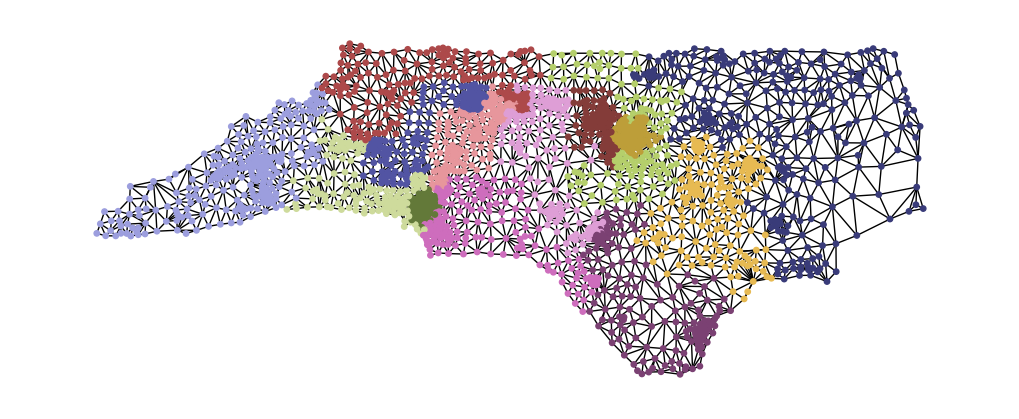

In [5]:
plt.figure(figsize=(10,4))
nx.draw(graph, pos={x:(graph.nodes()[x]['C_X'], graph.nodes()[x]['C_Y']) for x in graph.nodes()}, node_color=[graph.nodes()[x]['CON'] for x in graph.nodes()],cmap ='tab20b',node_size=15)

In [ ]:
def count_spanning(graph):
    laplacian = nx.laplacian_matrix(graph)
    L = np.delete(np.delete(laplacian.todense(), 0, 0), 1, 1)
    return np.linalg.slogdet(L)[1]

def county_splits(partition, df=df):
    df["current"] = df["PRECINCTID"].map(partition.assignment)

    counties = sum(df.groupby("COUNTYFP")['current'].nunique()>1)
    return counties

election_names = [
    "PRE",
    "GOV"
]

num_elections = len(election_names)

election_columns = [
  ['G24PRERTRU','G24PREDHAR'],
  ['G24GOVDSTE','G24GOVRROB']
]

my_updaters = {
    "population": updaters.Tally("population", alias="population"),
    "cut_edges": cut_edges,
    "PP":polsby_popper,
    "county_splits": county_splits
}

elections = [
    Election(
        election_names[i],
        {"Democratic": election_columns[i][1], "Republican": election_columns[i][0]},
    )
    for i in range(num_elections)
]

election_updaters = {election.name: election for election in elections}
for node in graph.nodes():
    graph.nodes()[node]["non_NH_Black"] = graph.nodes()[node]["population"] - graph.nodes()[node]["NH_Black"]

my_updaters.update({"NH_Black":Election("NH_Black",{"NH_Black": "NH_Black", "non_NH_Black": "non_NH_Black"})})
my_updaters.update()

# save percentages

my_updaters.update(election_updaters)


In [ ]:
# Recursive partitions (close to what redist does)

In [ ]:
ideal_population = df['population'].sum() / 14 # number of congressional districts
cd_dict = recursive_tree_part(graph, range(14), ideal_population, "population",.02)

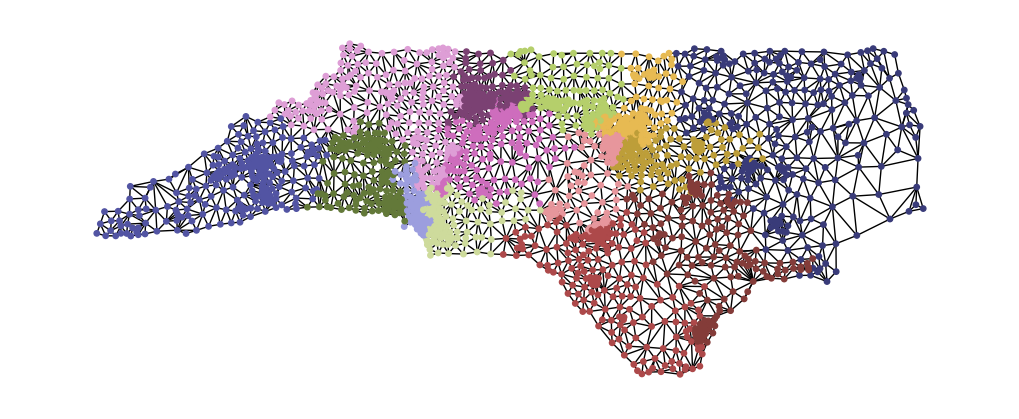

In [8]:
plt.figure(figsize=(10,4))
nx.draw(graph, pos={x:(graph.nodes()[x]['C_X'], graph.nodes()[x]['C_Y']) for x in graph.nodes()}, node_color=[cd_dict[x] for x in graph.nodes()],cmap ='tab20b',node_size=15)

In [ ]:
tree_partition = GeographicPartition(graph, cd_dict, my_updaters)

In [8]:
print(sum([1/x for x in polsby_popper(tree_partition).values()])/14)

print(mean_median(tree_partition["PRE"]))

print(tree_partition["county_splits"])


5.8623809738355
-0.026951815960500558
47


In [16]:
cs = [] # county splits
mms = [] # mean median
egs = [] # efficiency gap
pbs = [] # partisan bias
dvp = [] # dem voting perc
pps = [] # polsby popper
bvp = [] # black voting percent
mbvp = [] # max black voting percent
wins = [] # dem wins


for i in range(100): # num of trees to generate
    cd_dict = recursive_tree_part(graph, range(14), ideal_population, "population",.02)
    tree_partition = GeographicPartition(graph, cd_dict, my_updaters)

    cs.append(tree_partition['county_splits'])
    mms.append(mean_median(tree_partition['PRE']))
    egs.append(efficiency_gap(tree_partition['PRE']))
    pbs.append(partisan_bias(tree_partition['PRE']))
    dvp.append(sorted(tree_partition['PRE'].percents("Democratic")))
    pps.append(sum([1/x for x in polsby_popper(tree_partition).values()])/14)
    bvp.append(sorted(tree_partition['NH_Black'].percents("NH_Black")))
    mbvp.append(max(bvp[-1]))
    wins.append(tree_partition['PRE'].wins("Democratic"))

"""
    plt.figure(figsize=(10,4))
    nx.draw(graph, pos={x:(graph.nodes()[x]['C_X'], graph.nodes()[x]['C_Y']) for x in graph.nodes()}, node_color=[cd_dict[x] for x in graph.nodes()],cmap ='tab20b',node_size=15)
    plt.savefig(f'./NC_First_Ensemble_gif/network_plot_{i}.png')
    plt.close()

    df['current'] = df["PRECINCTID"].map(cd_dict)
    df.plot(column='current',cmap='tab20b')
    plt.axis('off')
    plt.savefig(f'./NC_First_Ensemble_gif/df_plot{i}.png')
    plt.close()
"""


C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\gerrychain\tree.py:704: BipartitionWarning: 
Failed to find a balanced cut after 1000 attempts.
If possible, consider enabling pair reselection within your
MarkovChain proposal method to allow the algorithm to select
a different pair of districts for recombination.
  warnings.warn(


'\n    plt.figure(figsize=(10,4))\n    nx.draw(graph, pos={x:(graph.nodes()[x][\'C_X\'], graph.nodes()[x][\'C_Y\']) for x in graph.nodes()}, node_color=[cd_dict[x] for x in graph.nodes()],cmap =\'tab20b\',node_size=15)\n    plt.savefig(f\'./NC_First_Ensemble_gif/network_plot_{i}.png\')\n    plt.close()\n\n    df[\'current\'] = df["PRECINCTID"].map(cd_dict)\n    df.plot(column=\'current\',cmap=\'tab20b\')\n    plt.axis(\'off\')\n    plt.savefig(f\'./NC_First_Ensemble_gif/df_plot{i}.png\')\n    plt.close()\n'

In [17]:
CONPart = GeographicPartition(graph, "CON", my_updaters)

In [17]:
CONPart['county_splits']

11

In [19]:
import numpy as np

plt.hist(cs)
plt.axvline((CONPart['county_splits']), color='red',label='Enacted')
plt.title("County splits")
plt.savefig('./NC_First_Ensemble_stats/cs.png')
plt.close()

plt.hist(mms)
plt.axvline(mean_median(CONPart["PRE"]), color='red',label='Enacted')
plt.title("Mean median")
plt.savefig('./NC_First_Ensemble_stats/mms.png')
plt.close()

plt.hist(egs)
plt.axvline(efficiency_gap(CONPart["PRE"]), color='red',label='Enacted')
plt.title("Efficiency gap")
plt.savefig('./NC_First_Ensemble_stats/egs.png')
plt.close()

plt.hist(pbs)
plt.axvline(partisan_bias(CONPart["PRE"]), color='red',label='Enacted')
plt.title("Partisan bias")
plt.savefig('./NC_First_Ensemble_stats/pbs.png')
plt.close()

dvp = np.array(dvp)
plt.boxplot(dvp)
plt.plot(range(1,15),(sorted(CONPart['PRE'].percents("Democratic"))), "*", color='red',label='Enacted')
plt.title("Dem voting percentage")
plt.savefig('./NC_First_Ensemble_stats/dvp.png')
plt.close()

plt.hist(pps)
plt.axvline(sum([1/x for x in polsby_popper(CONPart).values()])/14, color='red',label='Enacted')
plt.title("Polsby popper")
plt.savefig('./NC_First_Ensemble_stats/pps.png')
plt.close()

bvp = np.array(bvp)
plt.boxplot(bvp)
plt.plot(range(1,15),(sorted(CONPart['NH_Black'].percents("NH_Black"))), "*", color='red',label='NH_Black')
plt.title("Black voting percentage")
plt.savefig('./NC_First_Ensemble_stats/bvp.png')
plt.close()

plt.hist(wins)
plt.axvline(CONPart['PRE'].wins("Democratic"), color='red',label='Enacted')
plt.title("Dem wins")
plt.savefig('./NC_First_Ensemble_stats/wins.png')
plt.close()

In [ ]:
# ReCom Markov chains

In [37]:
# constraints
# Relevant NC metrics: Equal number of representatives (+/- 5% of ideal population)

def pp_constraint(partition):
    return sum([1/x for x in polsby_popper(partition).values()])/14 > 4

def county_constraint(partition):
    return partition['county_splits'] < 14

In [22]:
# proposal function
from functools import partial

proposal = partial(
    recom,
    pop_col="population",
    pop_target=ideal_population,
    epsilon=0.01,
    node_repeats=2
)

In [23]:
first_recom_chain = MarkovChain(
    proposal=proposal,
    constraints=[pp_constraint, county_constraint],
    accept=accept.always_accept,
    initial_state=CONPart,
    total_steps=100
)

In [ ]:
cs = [] # county splits
mms = [] # mean median
egs = [] # efficiency gap
pbs = [] # partisan bias
dvp = [] # dem voting perc
pps = [] # polsby popper
bvp = [] # black voting percent
mbvp = [] # max black voting percent
wins = [] # dem wins

i = 0

for part in first_recom_chain: # num of trees to generate

    i += 1

    cs.append(part['county_splits'])
    mms.append(mean_median(part['PRE']))
    egs.append(efficiency_gap(part['PRE']))
    pbs.append(partisan_bias(part['PRE']))
    dvp.append(sorted(part['PRE'].percents("Democratic")))
    pps.append(sum([1/x for x in polsby_popper(part).values()])/14)
    bvp.append(sorted(part['NH_Black'].percents("NH_Black")))
    mbvp.append(max(bvp[-1]))
    wins.append(part['PRE'].wins("Democratic"))

    ad = dict(part.assignment)

"""
    plt.figure(figsize=(10,4))
    nx.draw(graph, pos={x:(graph.nodes()[x]['C_X'], graph.nodes()[x]['C_Y']) for x in graph.nodes()}, node_color=[ad[x] for x in graph.nodes()],cmap ='tab20b',node_size=15)
    plt.savefig(f'./NC_Markov_gif_1/network_plot_{i}.png')
    plt.close()

    df['current'] = df["PRECINCTID"].map(ad)
    df.plot(column='current',cmap='tab20b')
    plt.axis('off')
    plt.savefig(f'./NC_Markov_gif_1/df_plot{i}.png')
    plt.close()
"""

In [27]:
plt.hist(cs)
plt.axvline((CONPart['county_splits']), color='red',label='Enacted')
plt.title("County splits")
plt.savefig('./NC_Markov_stats_1/cs.png')
plt.close()

plt.hist(mms)
plt.axvline(mean_median(CONPart["PRE"]), color='red',label='Enacted')
plt.title("Mean median")
plt.savefig('./NC_Markov_stats_1/mms.png')
plt.close()

plt.hist(egs)
plt.axvline(efficiency_gap(CONPart["PRE"]), color='red',label='Enacted')
plt.title("Efficiency gap")
plt.savefig('./NC_Markov_stats_1/egs.png')
plt.close()

plt.hist(pbs)
plt.axvline(partisan_bias(CONPart["PRE"]), color='red',label='Enacted')
plt.title("Partisan bias")
plt.savefig('./NC_Markov_stats_1/pbs.png')
plt.close()

dvp = np.array(dvp)
plt.boxplot(dvp)
plt.plot(range(1,15),(sorted(CONPart['PRE'].percents("Democratic"))), "*", color='red',label='Enacted')
plt.title("Dem voting percentage")
plt.savefig('./NC_Markov_stats_1/dvp.png')
plt.close()

plt.hist(pps)
plt.axvline(sum([1/x for x in polsby_popper(CONPart).values()])/14, color='red',label='Enacted')
plt.title("Polsby popper")
plt.savefig('./NC_Markov_stats_1/pps.png')
plt.close()

bvp = np.array(bvp)
plt.boxplot(bvp)
plt.plot(range(1,15),(sorted(CONPart['NH_Black'].percents("NH_Black"))), "*", color='red',label='NH_Black')
plt.title("Black voting percentage")
plt.savefig('./NC_Markov_stats_1/bvp.png')
plt.close()

plt.hist(wins)
plt.axvline(CONPart['PRE'].wins("Democratic"), color='red',label='Enacted')
plt.title("Dem wins")
plt.savefig('./NC_Markov_stats_1/wins.png')
plt.close()

In [39]:
# w/ new county surcharge that weights edges of counties more

county_proposal = partial(
    recom,
    pop_col="population",
    pop_target=ideal_population,
    epsilon=0.01,
    node_repeats=2,
    region_surcharge = {"COUNTYFP":1} # adds weight of one to the county edges
)

second_recom_chain = MarkovChain(
    proposal=county_proposal,
    constraints=[pp_constraint, county_constraint],
    accept=accept.always_accept,
    initial_state=CONPart,
    total_steps=5000
)

In [40]:
cs = [] # county splits
mms = [] # mean median
egs = [] # efficiency gap
pbs = [] # partisan bias
dvp = [] # dem voting perc
pps = [] # polsby popper
bvp = [] # black voting percent
mbvp = [] # max black voting percent
wins = [] # dem wins

i = 0

for part in second_recom_chain: # num of trees to generate

    i += 1
    if i %100 == 0:
        print(i)

    cs.append(part['county_splits'])
    mms.append(mean_median(part['PRE']))
    egs.append(efficiency_gap(part['PRE']))
    pbs.append(partisan_bias(part['PRE']))
    dvp.append(sorted(part['PRE'].percents("Democratic")))
    pps.append(sum([1/x for x in polsby_popper(part).values()])/14)
    bvp.append(sorted(part['NH_Black'].percents("NH_Black")))
    mbvp.append(max(bvp[-1]))
    wins.append(part['PRE'].wins("Democratic"))

    ad = dict(part.assignment)

    """
    plt.figure(figsize=(10,4))
    nx.draw(graph, pos={x:(graph.nodes()[x]['C_X'], graph.nodes()[x]['C_Y']) for x in graph.nodes()}, node_color=[ad[x] for x in graph.nodes()],cmap ='tab20b',node_size=15)
    plt.savefig(f'./NC_Markov_gif_2/network_plot_{i}.png')
    plt.close()

    df['current'] = df["PRECINCTID"].map(ad)
    df.plot(column='current',cmap='tab20b')
    plt.axis('off')
    plt.savefig(f'./NC_Markov_gif_2/df_plot{i}.png')
    plt.close()
    """


100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400


C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\gerrychain\tree.py:704: BipartitionWarning: 
Failed to find a balanced cut after 1000 attempts.
If possible, consider enabling pair reselection within your
MarkovChain proposal method to allow the algorithm to select
a different pair of districts for recombination.
  warnings.warn(


1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000


In [ ]:
plt.hist(cs)
plt.axvline((CONPart['county_splits']), color='red',label='Enacted')
plt.title("County splits")
plt.savefig('./NC_Markov_stats_5000/cs.png')
plt.close()

plt.hist(mms)
plt.axvline(mean_median(CONPart["PRE"]), color='red',label='Enacted')
plt.title("Mean median")
plt.savefig('./NC_Markov_stats_5000/mms.png')
plt.close()

plt.hist(egs,bins=100)
plt.axvline(efficiency_gap(CONPart["PRE"]), color='red',label='Enacted')
plt.title("Efficiency gap")
plt.savefig('./NC_Markov_stats_5000/egs.png')
plt.close()

plt.hist(pbs)
plt.axvline(partisan_bias(CONPart["PRE"]), color='red',label='Enacted')
plt.title("Partisan bias")
plt.savefig('./NC_Markov_stats_5000/pbs.png')
plt.close()

dvp = np.array(dvp)
plt.boxplot(dvp)
plt.plot(range(1,15),(sorted(CONPart['PRE'].percents("Democratic"))), "*", color='red',label='Enacted')
plt.title("Dem voting percentage")
plt.savefig('./NC_Markov_stats_5000/dvp.png')
plt.close()

plt.hist(pps)
plt.axvline(sum([1/x for x in polsby_popper(CONPart).values()])/14, color='red',label='Enacted')
plt.title("Polsby popper")
plt.savefig('./NC_Markov_stats_5000/pps.png')
plt.close()

bvp = np.array(bvp)
plt.boxplot(bvp)
plt.plot(range(1,15),(sorted(CONPart['NH_Black'].percents("NH_Black"))), "*", color='red',label='NH_Black')
plt.title("Black voting percentage")
plt.savefig('./NC_Markov_stats_5000/bvp.png')
plt.close()

plt.hist(wins)
plt.axvline(CONPart['PRE'].wins("Democratic"), color='red',label='Enacted')
plt.title("Dem wins")
plt.savefig('./NC_Markov_stats_5000/wins.png')
plt.close()

In [ ]:
# w/ new county surcharge that weights edges of counties more

county_proposal = partial(
    recom,
    pop_col="population",
    pop_target=ideal_population,
    epsilon=0.01,
    node_repeats=2,
    region_surcharge = {"COUNTYFP":1} # adds weight of one to the county edges
)

second_recom_chain = MarkovChain(
    proposal=county_proposal,
    constraints=[pp_constraint],
    accept=accept.always_accept,
    initial_state=CONPart,
    total_steps=100
)

In [ ]:
cs = [] # county splits
mms = [] # mean median
egs = [] # efficiency gap
pbs = [] # partisan bias
dvp = [] # dem voting perc
pps = [] # polsby popper
bvp = [] # black voting percent
mbvp = [] # max black voting percent
wins = [] # dem wins

i = 0

for part in second_recom_chain: # num of trees to generate

    i += 1
    

    cs.append(part['county_splits'])
    mms.append(mean_median(part['PRE']))
    egs.append(efficiency_gap(part['PRE']))
    pbs.append(partisan_bias(part['PRE']))
    dvp.append(sorted(part['PRE'].percents("Democratic")))
    pps.append(sum([1/x for x in polsby_popper(part).values()])/14)
    bvp.append(sorted(part['NH_Black'].percents("NH_Black")))
    mbvp.append(max(bvp[-1]))
    wins.append(part['PRE'].wins("Democratic"))

    ad = dict(part.assignment)


    plt.figure(figsize=(10,4))
    nx.draw(graph, pos={x:(graph.nodes()[x]['C_X'], graph.nodes()[x]['C_Y']) for x in graph.nodes()}, node_color=[ad[x] for x in graph.nodes()],cmap ='tab20b',node_size=15)
    plt.savefig(f'./NC_Markov_gif_2/network_plot_{i}.png')
    plt.close()

    df['current'] = df["PRECINCTID"].map(ad)
    df.plot(column='current',cmap='tab20b')
    plt.axis('off')
    plt.savefig(f'./NC_Markov_gif_2/df_plot{i}.png')
    plt.close()


In [ ]:
# steps are rows, columns are list

import pandas as pd

ndf = pd.DataFrame({"County splits":cs, "MM": mms, "EG": egs, "PB": pbs, "DWins": wins, "PP": pps})
ndf.to_csv("./NC_Markov_stats_2/initial_chain_outputs.csv")

# bvap and dvap --> vectors which can be separate files and round them

import csv
with open("./NC_Markov_stats_5000/DemPercs.csv","w") as tf1:
    writer = csv.writer(tf1, lineterminator="\n")
    writer.writerows(dvp)

with open("./NC_Markov_stats_5000/BlackPercs.csv","w") as tf1:
    writer = csv.writer(tf1, lineterminator="\n")
    writer.writerows(bvp)